Welcome to Machine Learning 101! Let's break down how we plot loss functions, why they look like bowls, and how they work in Polynomial Regression.

## 1. How a Loss Function is Plotted (Step-by-Step Example)

Think of a **loss function** as an "error meter." It measures how wrong our model's predictions are compared to actual ground truth.

Let's take a simple Linear Regression model predicting house price ($y$) using one feature, house size ($x_1$), with a second feature ($x_2$, say number of bedrooms) included:

$$
\hat{y} = w_1 x_1 + w_2 x_2 + b
$$

To simplify our plot, let's freeze the bias term at $b = 0$. Now, our prediction depends only on two parameters (weights): $w_1$ and $w_2$.

### The Plotting Recipe:

1. **Choose a grid of weights:** Pick various combinations of $(w_1, w_2)$, e.g., $w_1 \in [-5, 5]$ and $w_2 \in [-5, 5]$.
2. **Calculate predictions:** For each $(w_1, w_2)$ pair, compute $\hat{y}$ across all training samples.
3. **Compute the total loss:** Calculate the Mean Squared Error (MSE): $ J(w_1, w_2)$ = $\frac{1}{2m} \sum_{i=1}^{m} (\hat{y}^{(i)} - y^{(i)})^2$ 

4. **Plot in 3D Space:**
- **X-axis:** Weight $w_1$
- **Y-axis:** Weight $w_2$
- **Z-axis (Height):** Loss value $J(w_1, w_2)$

## 2. Why Does the Loss Function Look Like a Bowl?

When you plot $(w_1, w_2)$ on the floor and the Loss $J$ as height, the resulting surface forms a smooth **3D Paraboloid**—commonly called a **bowl shape** or a **convex surface**.

Here is why this mathematical shape occurs:

1. **Quadratic Nature of Mean Squared Error (MSE):** The prediction equation is linear with respect to weights: $\hat{y} = w_1 x_1 + w_2 x_2$. When you substitute this into the loss formula: $$ J(w_1, w_2) = \frac{1}{2m} \sum (w_1 x_1 + w_2 x_2 - y)^2 $$ Expanding the square produces terms like $w_1^2$, $w_2^2$, and $w_1 w_2$.
2. **Parabolas in 2D $\rightarrow$ Bowl in 3D:** If you vary just one weight, $f(w) = a w^2 + b w + c$ draws a 2D parabola (U-shape). Varying two weights simultaneously extends parabolas along both horizontal axes, forming a 3D bowl.
3. **Guaranteed Global Minimum (Convexity):** Because the squared error terms are strictly non-negative, the surface curves upwards in every direction away from the optimal weights $(w_1^*, w_2^*)$. The absolute lowest point at the bottom of the bowl represents the parameters with the minimum possible error.

## 3. How Loss is Calculated in Polynomial Regression

In **Polynomial Regression**, we model non-linear relationships by taking a feature $x$ and raising it to higher powers (e.g., $x^2, x^3$).

### Model Equation (Degree $d$ Polynomial):
$$

\hat{y} = w_0 + w_1 x + w_2 x^2 + w_3 x^3 + \dots + w_d x^d
$$

Notice that even though $x$ is non-linear, the equation is still **linear with respect to the weights** ($w_0, w_1, \dots, w_d$). We treat $x^2$ as a new feature $z_2$, $x^3$ as $z_3$, and so on.

### The Step-by-Step Loss Calculation Process:

1. **Forward Pass (Predicting):** For sample $i$ with feature $x^{(i)}$, compute predicted value $\hat{y}^{(i)}$: $$ \hat{y}^{(i)} = w_0 + w_1 x^{(i)} + w_2 (x^{(i)})^2 + \dots + w_d (x^{(i)})^d $$ where *d* is the the degree of x_i
2. **Compute Residual (Error per sample):** Find the difference between prediction and actual target $y^{(i)}$: $$ e^{(i)} = \hat{y}^{(i)} - y^{(i)} $$
3. **Square the Residual:** Squaring ensures positive and negative errors don't cancel each other out, while penalizing larger errors more heavily: $$ (e^{(i)})^2 = (\hat{y}^{(i)} - y^{(i)})^2 $$
4. **Average Across Dataset (Mean Squared Error):** Sum the squared residuals across all $m$ training samples and average them: $$ J(\mathbf{w}) = \frac{1}{2m} \sum_{i=1}^{m} \left( \left( w_0 + \sum_{j=1}^{d} w_j (x^{(i)})^j \right) - y^{(i)} \right)^2 $$

*(The factor of $\frac{1}{2}$ is added purely for mathematical convenience—it cancels out the 2 when taking derivatives during Gradient Descent).*

Because the loss function for Polynomial Regression remains quadratic with respect to weights $\mathbf{w}$, its loss landscape remains convex, ensuring Gradient Descent can reliably navigate down the bowl to find the best-fit curve!

******************************************

Let's work through a concrete numerical example of calculating the Mean Squared Error (MSE) loss for a **Quadratic (2nd-degree) Polynomial Regression** model step-by-step.

## 1. Setup: Data & Model Definition

### The Dataset ($m = 3$ samples)

Suppose we have $3$ data points $(x, y)$ representing an engine's running temperature ($x$) vs. fuel consumption ($y$):

| Sample ($i$) | Input ($x$) | Actual Target ($y$) |
| --- | --- | --- |
| **1** | $1$ | $3$ |
| **2** | $2$ | $7$ |
| **3** | $3$ | $13$ |

### Our Polynomial Hypothesis

We choose a degree-2 polynomial hypothesis function:

$$
\hat{y} = w_0 + w_1 x + w_2 x^2
$$

Suppose our current model parameters (weights) are:

- $w_0 = 1$ (bias)
- $w_1 = 1$
- $w_2 = 1$

So our specific prediction equation is:

$$
\hat{y} = 1 + 1(x) + 1(x^2) = 1 + x + x^2
$$

## 2. Step-by-Step Calculation

### Step 1: Compute Predictions ($\hat{y}$) for each sample

- **For Sample 1 ($x = 1$):** $$ \hat{y}^{(1)} = 1 + (1) + (1)^2 = 1 + 1 + 1 = 3 $$
- **For Sample 2 ($x = 2$):** $$ \hat{y}^{(2)} = 1 + (2) + (2)^2 = 1 + 2 + 4 = 7 $$
- **For Sample 3 ($x = 3$):** $$ \hat{y}^{(3)} = 1 + (3) + (3)^2 = 1 + 3 + 9 = 13 $$

### Step 2: Calculate Residuals, Errors, and Squared Errors

Now, let's compare our predictions ($\hat{y}$) with the actual targets ($y$):

| Sample ($i$) | Actual ($y$) | Predicted ($\hat{y}$) | Residual $(\hat{y} - y)$ | Squared Error $(\hat{y} - y)^2$ |
| --- | --- | --- | --- | --- |
| **1** | $3$ | $3$ | $3 - 3 = 0$ | $0^2 = 0$ |
| **2** | $7$ | $7$ | $7 - 7 = 0$ | $0^2 = 0$ |
| **3** | $13$ | $13$ | $13 - 13 = 0$ | $0^2 = 0$ |

For this exact parameter choice $(w_0=1, w_1=1, w_2=1)$, the squared error sum is **$0$** because the predictions perfectly match the target data.

### Step 3: Test a Suboptimal Parameter Set (Imperfections)

What if our optimization algorithm tested a different set of weights?

Let's try **$w_0 = 2, w_1 = 0.5, w_2 = 1$**.

Our new prediction equation is:
$$

\hat{y} = 2 + 0.5x + x^2

$$


Let's re-evaluate all 3 samples:

1. **Sample 1 ($x=1, y=3$):**
- $\hat{y}^{(1)} = 2 + 0.5(1) + (1)^2 = 3.5$
- Error: $\hat{y}^{(1)} - y^{(1)} = 3.5 - 3 = 0.5$
- Squared Error: $(0.5)^2 = \mathbf{0.25}$
2. **Sample 2 ($x=2, y=7$):**
- $\hat{y}^{(2)} = 2 + 0.5(2) + (2)^2 = 7.0$
- Error: $\hat{y}^{(2)} - y^{(2)} = 7.0 - 7 = 0.0$
- Squared Error: $(0.0)^2 = \mathbf{0.00}$
3. **Sample 3 ($x=3, y=13$):**
- $\hat{y}^{(3)} = 2 + 0.5(3) + (3)^2 = 12.5$
- Error: $\hat{y}^{(3)} - y^{(3)} = 12.5 - 13 = -0.5$
- Squared Error: $(-0.5)^2 = \mathbf{0.25}$

### Step 4: Aggregate into Final Loss $J(\mathbf{w})$

We use the standard Mean Squared Error formula:
$$

J(w_0, w_1, w_2) = \frac{1}{2m} \sum_{i=1}^{m} (\hat{y}^{(i)} - y^{(i)})^2

$$
Plugging in our values ($m = 3$):
$$

J(2, 0.5, 1) = \frac{1}{2 \times 3} (0.25 + 0.00 + 0.25)

$$
$$
J(2, 0.5, 1) = \frac{1}{6} (0.50) = \frac{0.50}{6} \approx \mathbf{0.0833}
$$

## Takeaway

- For the weights $(1, 1, 1)$, the loss $J = 0$ (the absolute bottom of our 3D bowl).
- For the weights $(2, 0.5, 1)$, the loss $J \approx 0.0833$ (a point slightly up on the walls of the bowl).
- Gradient descent uses the slope of this loss value with respect to $w_0, w_1, w_2$ to adjust the weights closer to $(1, 1, 1)$!

**********************************

Gradient descent is an optimization algorithm used to minimize error by iteratively adjusting parameters in the direction of steepest descent.


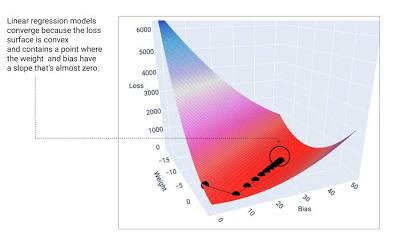

**1. The Setup & Dataset**

To see how the numbers update, let's use a minimal dataset of 3 data points representing **Study Hours ($x$) vs. Exam Score ($y$)**:

| Study Hours ($x$) | Actual Score ($y$) |
| --- | --- |
| 1 | 2 |
| 2 | 4 |
| 3 | 6 |

The true pattern is $y = 2x$. Our linear model attempts to learn this relationship:

$$
\hat{y} = w \cdot x
$$

- **Target Weight ($w^*$):** 2.0 (slope)
- **Initial Guess:** $w_0 = 0.0$
- **Learning Rate ($\alpha$):** 0.1 (controls the step size)

**2. Core Mathematical Formulas**

- **Mean Squared Error (MSE Loss):** $$ J(w) = \frac{1}{N} \sum_{i=1}^{N} (\hat{y}_i - y_i)^2 $$
- **Gradient (Derivative of Loss w.r.t Weight):** $$ \frac{\partial J}{\partial w} = \frac{2}{N} \sum_{i=1}^{N} x_i (\hat{y}_i - y_i) $$
- **Weight Update Rule:** $$ w_{\text{new}} = w_{\text{old}} - \alpha \cdot \frac{\partial J}{\partial w} $$

**3. Step-by-Step Optimization Trajectory**

**Iteration 1 (Starting at $w = 0.0$)**

1. **Predictions:** $\hat{y} = [0(1), 0(2), 0(3)] = [0, 0, 0]$ where 0(1) is w*x
2. **Errors ($E = \hat{y} - y$):** $[0 - 2, 0 - 4, 0 - 6] = [-2, -4, -6]$
3. **Current Loss:** $$ J(0) = \frac{1}{3} [(-2)^2 + (-4)^2 + (-6)^2] = \frac{56}{3} \approx 18.67 $$
4. **Compute Gradient:** $$ \frac{\partial J}{\partial w} = \frac{2}{3} [1(-2) + 2(-4) + 3(-6)] = \frac{2}{3} [-2 - 8 - 18] = -\frac{52}{3} \approx -17.33 $$
5. **Update Weight:** $$ w_1 = 0.0 - (0.1) \cdot (-17.33) = 1.733 $$

**Iteration 2 (Starting at $w = 1.733$)**

1. **Predictions:** $\hat{y} = [1.733, 3.466, 5.199]$
2. **Errors ($E = \hat{y} - y$):** $[-0.267, -0.534, -0.801]$
3. **Current Loss:** $$ J(1.733) = \frac{1}{3} [(-0.267)^2 + (-0.534)^2 + (-0.801)^2] \approx 0.33 $$
4. **Compute Gradient:** $$ \frac{\partial J}{\partial w} = \frac{2}{3} [1(-0.267) + 2(-0.534) + 3(-0.801)] \approx -4.98 $$
5. **Update Weight:** $$ w_2 = 1.733 - (0.1) \cdot (-4.98) = 2.231 $$

Notice how $w$ overshot slightly past 2.0 to 2.231.

**Iteration 3 (Starting at $w = 2.231$)**

1. **Gradient:** $$ \frac{\partial J}{\partial w} = \frac{2}{3} [1(0.231) + 2(0.462) + 3(0.693)] \approx +4.31 $$
2. **Update Weight:** $$ w_3 = 2.231 - (0.1) \cdot (+4.31) = 1.800 $$

**4. How Steps Change Over Time**

- **Negative Gradient:** Forces the weight to move right (increase).
- **Positive Gradient:** Forces the weight to move left (decrease).
- **Step Size Shrinkage:** As predictions approach $y$, the error terms $(\hat{y}_i - y_i)$ shrink toward zero. Smaller errors reduce the magnitude of the gradient, taking fine-grained steps as the parameter converges on $w = 2.0$.